In [2]:
import numpy as np
import os
import configparser
from distutils import util

import torch
import matplotlib

matplotlib.rcParams["text.usetex"] = False

import sys

sys.path.append("../")
from network import CycleSN
from training_fns import batch_to_cuda, create_synth_batch, CSNDataset
from analysis_fns import (
    plot_progress,
    plot_10_samples,
    plot_sample,
    apstarwavegrid,
    plot_spec_resid_density,
    tsne_domain_analysis2,
)

model_name = "kurucz_to_apogee_1"

use_cuda = torch.cuda.is_available()
if use_cuda:
    print("Using GPU!")
    torch.set_default_tensor_type("torch.cuda.FloatTensor")
else:
    torch.set_default_tensor_type("torch.FloatTensor")

Load the model configuration


In [3]:
# Directories
csn_dir = ".."
config_dir = os.path.join(csn_dir, "configs/")
model_dir = os.path.join(csn_dir, "models/")
progress_dir = os.path.join(csn_dir, "progress/")
data_dir = os.path.join(csn_dir, "data/")

# Model configuration
config = configparser.ConfigParser()
config.read(config_dir + model_name + ".ini")
architecture_config = config["ARCHITECTURE"]
print("\nCreating model: %s" % model_name)
print("\nConfiguration:")
for key_head in config.keys():
    if key_head == "DEFAULT":
        continue
    print("  %s" % key_head)
    for key in config[key_head].keys():
        print("    %s: %s" % (key, config[key_head][key]))

# DATA FILES
data_file_synth = os.path.join(data_dir, config["DATA"]["data_file_synth"])
data_file_obs = os.path.join(data_dir, config["DATA"]["data_file_obs"])
spectra_norm_file = os.path.join(data_dir, config["DATA"]["spectra_norm_file"])
emulator_fn = os.path.join(model_dir, config["DATA"]["emulator_fn"])


Creating model: kurucz_to_apogee_1

Configuration:
  DATA
    spectra_norm_file: mean_and_std_PAYNE_specs.npy
    data_file_synth: csn_kurucz.h5
    data_file_obs: csn_apogee.h5
    emulator_fn: PAYNE.pth.tar
    mask_fn: NA
  TRAINING
    batchsize: 8
    learning_rate_encoder: 0.0001
    learning_rate_decoder: 0.0001
    learning_rate_discriminator: 0.0001
    loss_weight_synth: 3
    loss_weight_obs: 9
    loss_weight_gen: 1
    loss_weight_dis: 1
    lr_decay_batch_iters_rg: [5e4,10e4,15e4,20e4,25e5]
    lr_decay_batch_iters_dis: [5e4,10e4,15e4,20e4,25e5]
    lr_decay_rg: 0.7
    lr_decay_dis: 0.7
    total_batch_iters: 5e5
    use_real_as_true: False
    mask_synth_lines: False
  ARCHITECTURE
    num_pixels: 7167
    activation: LeakyReLU
    conv_filts_ae_dom: [32, 64]
    conv_filt_lens_ae_dom: [7, 7]
    conv_strides_ae_dom: [4, 4]
    conv_filts_ae_sh: [128, 256, 512]
    conv_filt_lens_ae_sh: [7, 7, 7]
    conv_strides_ae_sh: [4, 2, 2]
    conv_filts_ae_sp: [32, 32, 32]
    

Construct the network architecture


In [4]:
# BUILD THE NETWORKS

print("\nBuilding networks...")
model = CycleSN(architecture_config, emulator_fn, use_cuda=use_cuda)

# Display model architectures
print("\n\nSYNTHETIC EMULATOR ARCHITECTURE:\n")
print(model.emulator)
print("\n\nENCODER_synth and ENCODER_obs ARCHITECTURE:\n")
print(model.encoder_synth)
print("\n\nENCODER_sh ARCHITECTURE:\n")
print(model.encoder_sh)
if model.use_split:
    print("\n\nENCODER_sp ARCHITECTURE:\n")
    print(model.encoder_sp)
    print("\n\nDECODER_sp ARCHITECTURE:\n")
    print(model.decoder_sp)
print("\n\nDECODER_sh ARCHITECTURE:\n")
print(model.decoder_sh)
print("\n\nDECODER_synth and DECODER_obs ARCHITECTURE:\n")
print(model.decoder_synth)
print("\n\nDISCRIM_synth and DISCRIM_obs ARCHITECTURE:\n")
print(model.discriminator_synth)


Building networks...


SYNTHETIC EMULATOR ARCHITECTURE:

Sequential(
  (0): Linear(in_features=25, out_features=300, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=300, out_features=300, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=300, out_features=7214, bias=True)
)


ENCODER_synth and ENCODER_obs ARCHITECTURE:

Sequential(
  (0): Conv1d(1, 32, kernel_size=(7,), stride=(4,))
  (1): LeakyReLU(negative_slope=0.1)
  (2): Conv1d(32, 64, kernel_size=(7,), stride=(4,))
  (3): LeakyReLU(negative_slope=0.1)
)


ENCODER_sh ARCHITECTURE:

Sequential(
  (0): Conv1d(64, 128, kernel_size=(7,), stride=(4,))
  (1): LeakyReLU(negative_slope=0.1)
  (2): Conv1d(128, 256, kernel_size=(7,), stride=(2,))
  (3): LeakyReLU(negative_slope=0.1)
  (4): Conv1d(256, 512, kernel_size=(7,), stride=(2,))
  (5): LeakyReLU(negative_slope=0.1)
  (6): Conv1d(512, 25, kernel_size=(1,), stride=(1,))
  (7): InstanceNorm1d(25, eps=1e-05, momentum=0.1, affine=False

Load the pre-trained weights for the network


In [5]:
torch.serialization.add_safe_globals([np.core.multiarray.scalar])
torch.serialization.safe_globals([np.dtype])

/var/folders/fh/60531mhj3zx8hjh_bz5t8z1w0000gn/T/ipykernel_36878/1671194897.py:1: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  torch.serialization.add_safe_globals([np.core.multiarray.scalar])


In [6]:
model_filename = os.path.join(model_dir, model_name + ".pth.tar")

print("\nLoading saved model...")
# Load model info
checkpoint = torch.load(
    model_filename, map_location=lambda storage, loc: storage, weights_only=False
)
losses = dict(checkpoint["losses"])

# Load model weights
model.load_state_dict(checkpoint["cycle_model"])


Loading saved model...


<All keys matched successfully>

Display the training progress


kurucz_to_apogee_1


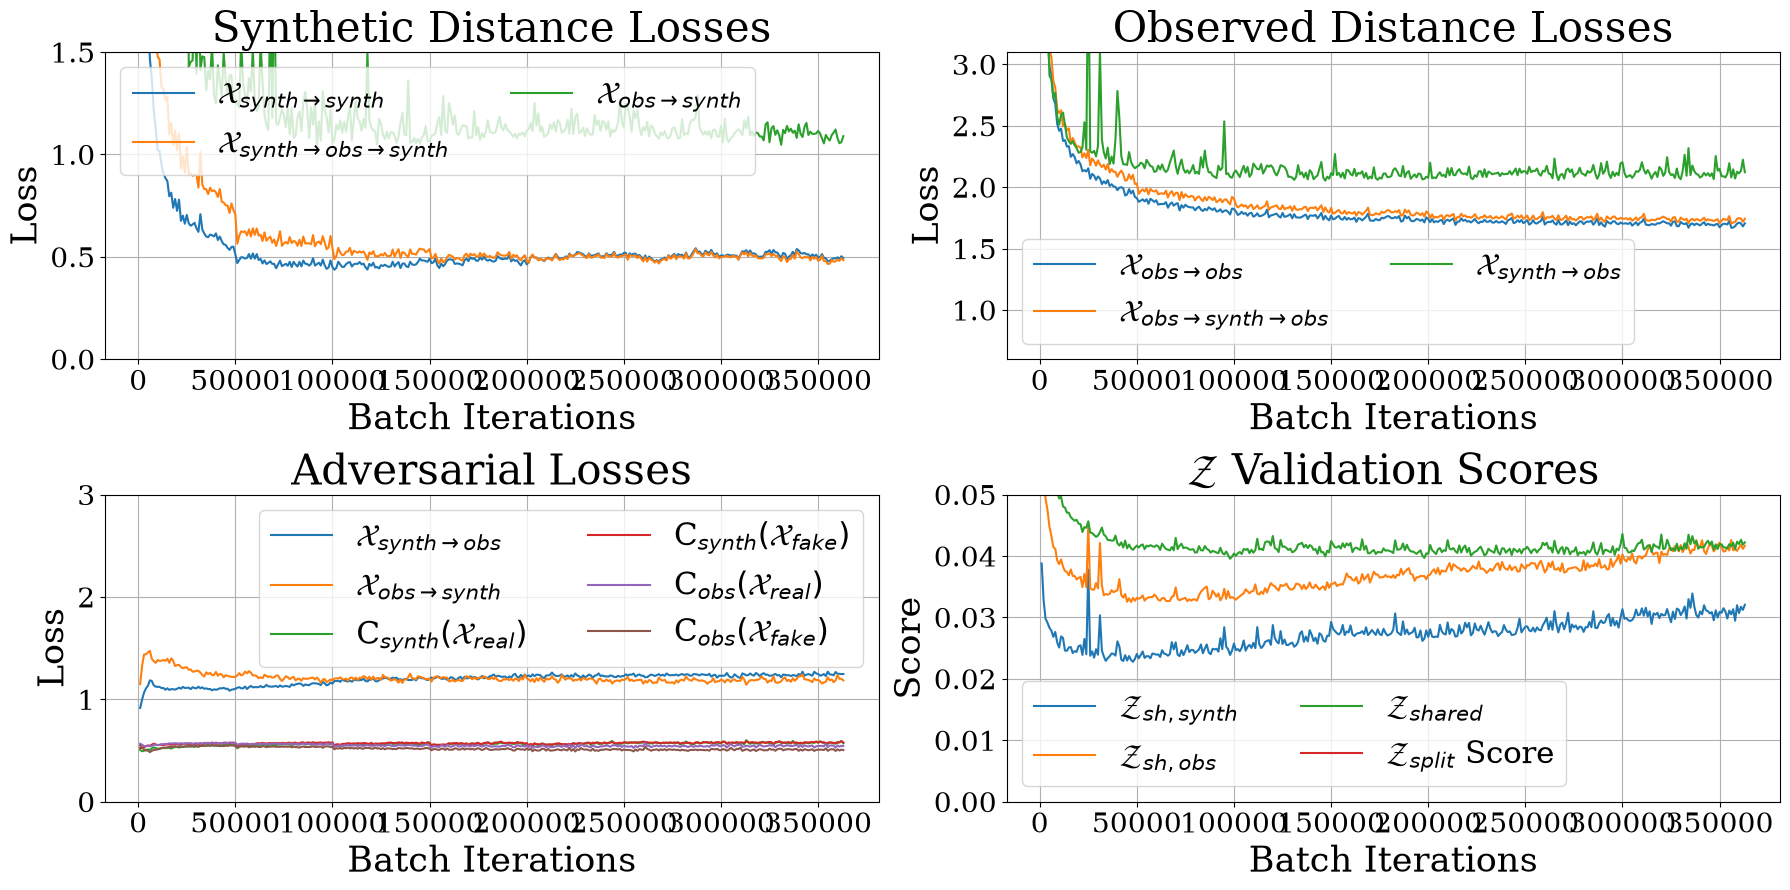

In [7]:
%matplotlib inline
print(model_name)
plot_progress(losses, y_lims=[(0,1.5),(0.6,3.1),(0,3),(0,0.05)])#, 
              #savename='../figures/'+model_name+'_training_progress.png')

Load a batch of test spectra


In [15]:
num_spec = 7000
dataset = "test"

# Normalization data for the spectra
x_mean, x_std = np.load(spectra_norm_file)

# Load ASPCAP wave-grid
wave_grid = apstarwavegrid()[47:]

mask_synth_lines = bool(util.strtobool(config["TRAINING"]["mask_synth_lines"]))
if mask_synth_lines:
    print("Using line mask.")
    # Load line mask
    line_mask = np.load(data_dir + "mock_missing_lines.npz")["total_mask"]
    line_mask = torch.from_numpy(np.array(line_mask, dtype=np.uint8))
else:
    # Don't use line mask
    line_mask = None

# A set of observed spectra
obs_dataset = CSNDataset(
    data_file_obs, dataset=dataset, x_mean=x_mean, x_std=x_std, line_mask=None
)
obs_batch = obs_dataset.__getitem__(np.arange(num_spec))
# Generate synth batch of matching spectra
synth_batch = create_synth_batch(
    model, x_mean, x_std, obs_batch["y"], line_mask=line_mask, use_cuda=use_cuda
)

# Switch to GPU
if use_cuda:
    obs_batch = batch_to_cuda(obs_batch)
    synth_batch = batch_to_cuda(synth_batch)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../data/csn_apogee.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Compute all of the different mappings using our set of spectra


In [ ]:
# Evaluate validation set
model.eval_mode()

with torch.no_grad():
    # Encoding
    zsh_synth = model.synth_to_z(synth_batch["x"])
    if model.use_split:
        zsh_obs, zsp_obs = model.obs_to_z(obs_batch["x"])
        zsh_obs = zsh_obs
        zsp_obs = zsp_obs
    else:
        zsh_obs = model.obs_to_z(obs_batch["x"])

    # Reconstruction
    x_synthsynth = model.z_to_synth(zsh_synth)
    if model.use_split:
        x_obsobs = model.z_to_obs(zsh_obs, zsp_obs)
    else:
        x_obsobs = model.z_to_obs(zsh_obs)

    # Cross-domain mapping
    if model.use_split:
        # Here we use the z_split from x_obs to generate x_synthobs
        x_synthobs = model.z_to_obs(zsh_synth, zsp_obs)
    else:
        x_synthobs = model.z_to_obs(zsh_synth)
    x_obssynth = model.z_to_synth(zsh_obs)

    # Cycle-Reconstruction
    zsh_obssynth = model.synth_to_z(x_obssynth)
    if model.use_split:
        zsh_synthobs, zsp_synthobs = model.obs_to_z(x_synthobs)
        zsh_synthobs = zsh_synthobs
        zsp_synthobs = zsp_synthobs
        # Here we again use the original z_split from x_obs to cycle-reconstuct x_obssynthobs
        x_obssynthobs = model.z_to_obs(zsh_obssynth, zsp_obs)
    else:
        zsh_synthobs = model.obs_to_z(x_synthobs)
        x_obssynthobs = model.z_to_obs(zsh_obssynth)
    x_synthobssynth = model.z_to_synth(zsh_synthobs)

In [ ]:
# Return to numpy
x_synth = synth_batch["x"].data.cpu().numpy()
x_obs = obs_batch["x"].data.cpu().numpy()
zsh_synth = zsh_synth.data.cpu().numpy()
zsh_obs = zsh_obs.data.cpu().numpy()
x_synthsynth = x_synthsynth.data.cpu().numpy()
x_obsobs = x_obsobs.data.cpu().numpy()
x_synthobs = x_synthobs.data.cpu().numpy()
x_obssynth = x_obssynth.data.cpu().numpy()
x_synthobssynth = x_synthobssynth.data.cpu().numpy()
x_obssynthobs = x_obssynthobs.data.cpu().numpy()
x_obs_msk = obs_batch["x_msk"].data.cpu().numpy()
x_obs_err = obs_batch["x_err"].data.cpu().numpy()
snr_obs = obs_batch["snr"].data.cpu().numpy()
y_obs = obs_batch["y"].data.cpu().numpy()

# Denormalize
x_synth = x_synth * x_std + x_mean
x_obs = x_obs * x_std + x_mean
x_synthsynth = x_synthsynth * x_std + x_mean
x_obsobs = x_obsobs * x_std + x_mean
x_synthobs = x_synthobs * x_std + x_mean
x_obssynth = x_obssynth * x_std + x_mean
x_synthobssynth = x_synthobssynth * x_std + x_mean
x_obssynthobs = x_obssynthobs * x_std + x_mean
x_obs_err = x_obs_err * x_std

Analyze a few of the spectra.

First, let's take a look at the cycle-reconstructed observed spectra (double click on the figure to enlarge)


In [ ]:
# Randomly select 10 indices
test_indices = np.random.choice(np.arange(0, len(x_obs)), size=10, replace=False)

plot_10_samples(
    wave_grid,
    x_obs,
    x_obssynthobs,
    test_indices,
    labels=[r"$x_{obs}$", r"$x_{obs\rightarrow synth \rightarrow obs}$"],
)

Now the cycle-reconstructed synthetic spectra


In [ ]:
plot_10_samples(
    wave_grid,
    x_synth,
    x_synthobssynth,
    test_indices,
    labels=[r"$x_{synth}$", r"$x_{synth\rightarrow obs \rightarrow synth}$"],
)

and the mapping from synthetic to observed


In [ ]:
plot_10_samples(
    wave_grid,
    x_obs,
    x_synthobs,
    test_indices,
    labels=[r"$x_{obs}$", r"$x_{synth \rightarrow obs}$"],
)

finally the mapping from observed to synthetic


In [ ]:
plot_10_samples(
    wave_grid,
    x_synth,
    x_obssynth,
    test_indices,
    labels=[r"$x_{synth}$", r"$x_{obs \rightarrow synth}$"],
)

We can take a closer look at a single spectrum


In [ ]:
indx = np.argsort(snr_obs)[30]
min_wave = 15200  # in Angstroms
max_wave = 15550
print(y_obs[indx])
print(snr_obs[indx])
plot_sample(
    wave_grid,
    x_obs,
    x_synth,
    x_synthobs,
    x_obs_err,
    x_obs_msk,
    indx,
    min_wave=min_wave,
    max_wave=max_wave,
    savename="../figures/sample.pdf",
)

Now lets quantify these reconstructions for the entire set of spectra


In [ ]:
print(model_name)
num_spec = 7000
resid = [
    (x_synthsynth[:num_spec] - x_synth[:num_spec]) / x_synth[:num_spec],
    (x_synthobssynth[:num_spec] - x_synth[:num_spec]) / x_synth[:num_spec],
]

# Plot residual
plot_spec_resid_density(
    wave_grid,
    resid,
    x_obs_msk[:num_spec],
    labels=[
        r"$\frac{\mathbf{\mathcal{X}_{synth\rightarrow synth}} - \mathbf{\mathcal{X}_{synth}}}{\mathbf{\mathcal{X}_{synth}}}$",
        r"$\frac{\mathbf{\mathcal{X}_{synth\rightarrow obs\rightarrow synth}} - \mathbf{\mathcal{X}_{synth}}}{\mathbf{\mathcal{X}_{synth}}}$",
    ],
    ylim=(-0.06, 0.06),
    hist=True,
    kde=False,
    dist_bins=1000,
    hex_grid=300,
    bias="mean",
    bias_label=r"$\overline{x}$ \ ",
    cmap="gist_earth_r",
    savename="../figures/synth_rec.png",
)

resid = [
    (x_obsobs[:num_spec] - x_obs[:num_spec]) / x_obs_err[:num_spec],
    (x_obssynthobs[:num_spec] - x_obs[:num_spec]) / x_obs_err[:num_spec],
]

# Plot residual
plot_spec_resid_density(
    wave_grid,
    resid,
    x_obs_msk[:num_spec],
    labels=[
        r"$\frac{\mathbf{\mathcal{X}_{obs\rightarrow obs}} - \mathbf{\mathcal{X}_{obs}}}{\mathbf{\sigma_{obs}}}$",
        r"$\frac{\mathbf{\mathcal{X}_{obs\rightarrow synth\rightarrow obs}} - \mathbf{\mathcal{X}_{obs}}}{\mathbf{\sigma_{obs}}}$",
    ],
    ylim=(-12, 12),
    hist=True,
    kde=False,
    dist_bins=2000,
    hex_grid=1000,
    bias="mean",
    bias_label="$\overline{x}$ \ ",
    cmap="gist_earth_r",
    savename="../figures/obs_rec.png",
)

resid = [
    (x_synth[:num_spec] - x_obs[:num_spec]) / x_obs_err[:num_spec],
    (x_synthobs[:num_spec] - x_obs[:num_spec]) / x_obs_err[:num_spec],
]

# Plot residual
plot_spec_resid_density(
    wave_grid,
    resid,
    x_obs_msk[:num_spec],
    labels=[
        r"$\frac{\mathbf{\mathcal{X}_{synth}} - \mathbf{\mathcal{X}_{obs}}}{\mathbf{\sigma_{obs}}}$",
        r"$\frac{\mathbf{\mathcal{X}_{synth\rightarrow obs}} - \mathbf{\mathcal{X}_{obs}}}{\mathbf{\sigma_{obs}}}$",
    ],
    ylim=(-15, 15),
    hist=True,
    kde=False,
    dist_bins=2000,
    hex_grid=300,
    bias="mean",
    bias_label="$\overline{x}$ \ ",
    cmap="gist_earth_r",
    savename="../figures/kurucz_vs_csn.png",
)

In [ ]:
print(model_name)
num_spec = 7000

tsne_domain_analysis2(
    x_synth[:num_spec],
    x_obsobs[:num_spec],
    x_synthobs[:num_spec],
    zsh_synth=zsh_synth[:num_spec],
    zsh_obs=zsh_obs[:num_spec],
    x_obs_label=r"$\mathbf{\mathcal{X}_{obs\rightarrow obs}}$",
    savename="../figures/apogee_tsne.png",
)

Some stuff for analyzing the derivatives:


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rc("text", usetex=True)
plt.rc("font", family="serif")

In [ ]:
# Choose a set of input labels.

# The order of the labels are:
# Teff, Logg, Vturb [km/s],
# [C/H], [N/H], [O/H], [Na/H], [Mg/H],
# [Al/H], [Si/H], [P/H], [S/H], [K/H],
# [Ca/H], [Ti/H], [V/H], [Cr/H], [Mn/H],
# [Fe/H], [Co/H], [Ni/H], [Cu/H], [Ge/H],
# C12/C13, Vmacro [km/s]
ref_labels = np.array(
    [
        [
            4750.0,
            2.5,
            1.5,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            7.5,
            6.0,
        ]
    ]
)
ref_labels = torch.from_numpy(ref_labels.astype(np.float32))

# Get an average z_split from the observations as our reference
if model.use_split:
    z_split = torch.mean(model.obs_to_z(obs_batch["x"])[1], 0, keepdim=True)
else:
    z_split = None


def y_to_synth(y):

    # Produce synthetic spectrum
    x = model.emulator(y)

    # Return last 7167 pixels
    return x[:, 47:]


def y_to_synth_to_synth(y):

    # Produce synthetic spectrum with masked lines
    x = y_to_synth(y)

    # Normalize
    x = (x - x_mean) / x_std

    # Encode the synthetic spectrum
    z = model.synth_to_z(x)

    # Decode the latent variables into the synthetic domain
    x = model.z_to_synth(z)

    # Return to the regular continuum level and scale
    x = x * x_std + x_mean

    return x


def y_to_synth_to_obs(y, z_sp=None):

    # Produce synthetic spectrum with masked lines
    x = y_to_synth(y)

    # Normalize
    x = (x - x_mean) / x_std

    # Encode the synthetic spectrum
    z = model.synth_to_z(x)

    # Decode the latent variables into the observed domain
    if z_split is not None:
        x = model.z_to_obs(z, z_sp)
    else:
        x = model.z_to_obs(z)
    # Return to the regular continuum level and scale
    x = x * x_std + x_mean

    return x

Calculate Jacobians


In [ ]:
jac_synth = np.zeros((int(config["ARCHITECTURE"]["num_pixels"]), 25))
jac_synthobs = np.zeros((int(config["ARCHITECTURE"]["num_pixels"]), 25))

for ele_index in range(25):

    # Deviate reference labels
    deviate_labels = torch.clone(ref_labels)
    deviate_labels[0, ele_index] += 0.05

    # Scale labels for emulator input
    y = (ref_labels - model.y_min) / (model.y_max - model.y_min) - 0.5
    y_dev = (deviate_labels - model.y_min) / (model.y_max - model.y_min) - 0.5

    # Create a synthetic spectrum
    x_synth = y_to_synth(y).data.numpy()
    x_synth_dev = y_to_synth(y_dev).data.numpy()

    # Create observed spectrum
    x_synthobs = y_to_synth_to_obs(y, z_split).data.numpy()
    x_synthobs_dev = y_to_synth_to_obs(y_dev, z_split).data.numpy()

    # Calculate difference
    jac_synth[:, ele_index] = x_synth_dev - x_synth
    jac_synthobs[:, ele_index] = x_synthobs_dev - x_synthobs

# Only select abundances
jac_synthobs = jac_synthobs[:, 3:-2]
jac_synth = jac_synth[:, 3:-2]

# Calculate difference
jac_diff = jac_synthobs - jac_synth

In [ ]:
print(model_name)

# Choose an element:
elem_labels = [
    "[C/H]",
    "[N/H]",
    "[O/H]",
    "[Na/H]",
    "[Mg/H]",
    "[Al/H]",
    "[Si/H]",
    "[P/H]",
    "[S/H]",
    "[K/H]",
    "[Ca/H]",
    "[Ti/H]",
    "[V/H]",
    "[Cr/H]",
    "[Mn/H]",
    "[Fe/H]",
    "[Co/H]",
    "[Ni/H]",
    "[Cu/H]",
    "[Ge/H]",
]

elem_indices = [3, 4, 8, 9, 18]

for ele_index in elem_indices:

    plt.close("all")
    print(elem_labels[ele_index])
    # Plot test results
    fig, axes = plt.subplots(3, 1, figsize=(50, 15), sharex=True)
    (j_synth,) = axes[0].plot(wave_grid, jac_synth[:, ele_index], c="maroon")
    (j_obs,) = axes[1].plot(wave_grid, jac_synthobs[:, ele_index], c="navy")
    (j_diff,) = axes[2].plot(wave_grid, jac_diff[:, ele_index], c="mediumvioletred")

    for i in range(3):
        axes[i].tick_params(labelsize=15)

    axes[0].set_ylim((-0.005, 0.001))
    axes[1].set_ylim((-0.005, 0.001))
    axes[2].set_ylim((-0.001, 0.001))

    axes[0].set_ylabel(r"$\partial$Flux", fontsize=22, labelpad=15)
    axes[1].set_ylabel(r"$\partial$Flux", fontsize=22, labelpad=15)
    axes[2].set_ylabel(r"$\partial$Flux", fontsize=22)
    plt.xlabel(r"Wavelength (\AA)", fontsize=22)

    axes[0].set_title(
        r"$\frac{\partial{\mathbf{x_{synth}}}}{\partial{y_j}}$", fontsize=20
    )
    axes[1].set_title(
        r"$\frac{\partial{\mathbf{x_{synth \rightarrow obs}}}}{\partial{y_j}}$",
        fontsize=20,
    )
    axes[2].set_title(
        r"$\frac{\partial{\mathbf{x_{synth \rightarrow obs}}}}{\partial{y_j}}-\frac{\partial{\mathbf{x_{synth}}}}{\partial{y_j}}$",
        fontsize=20,
    )

    plt.tight_layout()
    plt.show()